In [1]:
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import random
import hashlib
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
random.seed(42)

In [2]:
hospitals = [
    'Apollo Hospital Mumbai', 'Fortis Hospital Delhi',
    'AIIMS Delhi', 'Max Hospital Bangalore',
    'Ruby Hall Pune', 'Manipal Hospital Chennai',
    'Kokilaben Hospital Mumbai', 'Medanta Gurgaon',
    'Care Hospital Hyderabad', 'Columbia Asia Bangalore'
]


diagnoses = {
    'Appendectomy': (40000, 120000),
    'Knee Replacement': (150000, 400000),
    'Heart Bypass': (300000, 700000),
    'Gallbladder Removal': (50000, 150000),
    'Cataract Surgery': (15000, 60000),
    'Fracture Treatment': (30000, 100000),
    'Dengue Fever': (15000, 50000),
    'Typhoid Treatment': (10000, 40000),
    'Kidney Stone Removal': (60000, 180000),
    'Hernia Surgery': (45000, 130000),
    'Cancer Chemotherapy': (200000, 600000),
    'Dialysis': (20000, 80000),
    'Brain Tumor Surgery': (400000, 900000),
    'Spine Surgery': (200000, 500000),
    'Hip Replacement': (180000, 450000)
}

first_names = [
    'Rajesh', 'Priya', 'Amit', 'Sunita', 'Vikram',
    'Deepa', 'Suresh', 'Kavita', 'Rohit', 'Anjali',
    'Ramesh', 'Neha', 'Sanjay', 'Pooja', 'Arun',
    'Meena', 'Prakash', 'Rekha', 'Vinod', 'Shobha'
]

last_names = [
    'Sharma', 'Patel', 'Kumar', 'Singh', 'Mehta',
    'Joshi', 'Gupta', 'Nair', 'Rao', 'Desai',
    'Shah', 'Verma', 'Mishra', 'Tiwari', 'Pandey'
]

def generate_policy_number(idx, is_fraud):
    if is_fraud:
        # Fraud policies tend to be newer
        year = random.randint(2023, 2025)
    else:
        year = random.randint(2015, 2023)
    return f"LIC-{year}-{str(idx).zfill(4)}"

def generate_start_date(policy_number):
    year = int(policy_number.split('-')[1])
    month = random.randint(1, 12)
    day = random.randint(1, 28)
    return datetime(year, month, day)


# 400 legitimate policyholders, 100 fraudulent
policies = []

for i in range(1, 501):
    is_fraud_policy = i > 400  
    
    name = f"{random.choice(first_names)} {random.choice(last_names)}"
    policy_number = generate_policy_number(i, is_fraud_policy)
    start_date = generate_start_date(policy_number)
    
    if is_fraud_policy:
        monthly_premium = random.randint(500, 2000)
        coverage_amount = random.randint(100000, 500000)
    else:
        monthly_premium = random.randint(1000, 8000)
        coverage_amount = random.randint(300000, 2000000)
    
    policies.append({
        'policy_number': policy_number,
        'patient_name': name,
        'patient_age': random.randint(18, 80),
        'policy_start_date': start_date.strftime('%Y-%m-%d'),
        'monthly_premium': monthly_premium,
        'coverage_amount': coverage_amount,
        'is_fraud_prone': int(is_fraud_policy)
    })

df_policies = pd.DataFrame(policies)
print(f"Policies generated: {len(df_policies)}")
print(f"Fraud prone policies: {df_policies['is_fraud_prone'].sum()}")
print(df_policies.head())

Policies generated: 500
Fraud prone policies: 100
   policy_number   patient_name  patient_age policy_start_date  \
0  LIC-2019-0001  Sunita Sharma           24        2019-04-08   
1  LIC-2021-0002    Rekha Patel           32        2021-01-01   
2  LIC-2015-0003  Prakash Desai           62        2015-09-07   
3  LIC-2018-0004    Rekha Gupta           73        2018-08-19   
4  LIC-2017-0005  Rajesh Mishra           27        2017-12-14   

   monthly_premium  coverage_amount  is_fraud_prone  
0             2143          1844492               0  
1             1767           758517               0  
2             6865          1662906               0  
3             3278          1997498               0  
4             3787           882738               0  


In [3]:
claims = []
claim_id = 1

reference_date = datetime(2026, 1, 1)

for _, policy in df_policies.iterrows():
    policy_start = datetime.strptime(policy['policy_start_date'], '%Y-%m-%d')
    policy_age_months = max(1, (reference_date - policy_start).days // 30)
    is_fraud_prone = policy['is_fraud_prone']
    
    # Fraud prone policies make more claims
    if is_fraud_prone:
        num_claims = random.randint(4, 10)
    else:
        num_claims = random.randint(1, 3)
    
    policy_claims = []
    
    # Track claims per year to avoid too many in same year
    claims_per_year = {}

    for j in range(num_claims):
    # Treatment date - spread across policy lifetime
        max_days = (reference_date - policy_start).days
        if max_days < 31:
            continue
        days_after_start = random.randint(30, max_days)
        treatment_date = policy_start + timedelta(days=days_after_start)
    
    # Check claims per year limit
        year = treatment_date.year
        if year not in claims_per_year:
            claims_per_year[year] = 0
    
    # Max 2 claims per year for legit, 3 for fraud
        max_per_year = 3 if is_fraud_prone else 2
        if claims_per_year[year] >= max_per_year:
            continue
        claims_per_year[year] += 1

    # Pick diagnosis and get realistic amount
        diagnosis = random.choice(list(diagnoses.keys()))
        hospital = random.choice(hospitals)
        amount_min, amount_max = diagnoses[diagnosis]

        if is_fraud_prone:
            claim_amount = random.uniform(amount_min * 1.5, amount_max * 2.5)

            hospital_stay_days = random.randint(8, 25)
            num_procedures = random.randint(6, 12)
            num_diagnoses = random.randint(3, 6)
            doctor_experience_years = random.randint(1, 8)
        else:
        # Legit: realistic amount for diagnosis
            claim_amount = random.uniform(amount_min, amount_max)
            hospital_stay_days = random.randint(1, 7)
            num_procedures = random.randint(1, 4)
            num_diagnoses = random.randint(1, 2)
            doctor_experience_years = random.randint(8, 35)
        

        # Auto-calculate derived features
        num_claims_last_year = sum(
            1 for c in policy_claims
            if (treatment_date - datetime.strptime(c['treatment_date'], '%Y-%m-%d')).days <= 365
        )
        claim_to_premium_ratio = round(
            claim_amount / max(1, policy['monthly_premium'] * policy_age_months), 2
        )

        # Is duplicate - fraud policies more likely
        if is_fraud_prone and len(policy_claims) > 0:
            is_duplicate = 1 if random.random() < 0.4 else 0
        else:
            is_duplicate = 0

        
        # Fraud if: high ratio + duplicate + many claims + short policy
        fraud_score = 0
        if claim_to_premium_ratio > 15: fraud_score += 3
        if is_duplicate: fraud_score += 3
        if num_claims_last_year > 4: fraud_score += 2
        if policy_age_months < 6: fraud_score += 2
        if num_procedures > 8: fraud_score += 1
        if hospital_stay_days > 15: fraud_score += 1
# Only flag as fraud if claim is significantly inflated
        if claim_amount > amount_max * 1.5: fraud_score += 3
# Penalize small claims - they should never be fraud
        if claim_amount < amount_min * 1.5: fraud_score -= 6
        Class = 1 if (is_fraud_prone and fraud_score >= 7) else 0
        claim = {
            'claim_id': claim_id,
            'policy_number': policy['policy_number'],
            'patient_name': policy['patient_name'],
            'patient_age': policy['patient_age'],
            'hospital_name': hospital,
            'diagnosis_type': diagnosis,
            'claim_amount': round(claim_amount, 2),
            'hospital_stay_days': hospital_stay_days,
            'num_procedures': num_procedures,
            'num_diagnoses': num_diagnoses,
            'doctor_experience_years': doctor_experience_years,
            'num_claims_last_year': num_claims_last_year,
            'policy_age_months': policy_age_months,
            'claim_to_premium_ratio': claim_to_premium_ratio,
            'is_duplicate_claim': is_duplicate,
            'treatment_date': treatment_date.strftime('%Y-%m-%d'),
            'monthly_premium': policy['monthly_premium'],
            'Class': Class
        }

        claims.append(claim)
        policy_claims.append(claim)
        claim_id += 1
    

df_claims = pd.DataFrame(claims)

print(f"Total claims: {len(df_claims)}")
print(f"Fraud claims: {df_claims['Class'].sum()}")
print(f"Legit claims: {(df_claims['Class']==0).sum()}")
print(f"Fraud rate: {df_claims['Class'].mean()*100:.2f}%")
print(f"\nSample columns: {list(df_claims.columns)}")
print(df_claims.head())

Total claims: 1274
Fraud claims: 166
Legit claims: 1108
Fraud rate: 13.03%

Sample columns: ['claim_id', 'policy_number', 'patient_name', 'patient_age', 'hospital_name', 'diagnosis_type', 'claim_amount', 'hospital_stay_days', 'num_procedures', 'num_diagnoses', 'doctor_experience_years', 'num_claims_last_year', 'policy_age_months', 'claim_to_premium_ratio', 'is_duplicate_claim', 'treatment_date', 'monthly_premium', 'Class']
   claim_id  policy_number   patient_name  patient_age  \
0         1  LIC-2019-0001  Sunita Sharma           24   
1         2  LIC-2019-0001  Sunita Sharma           24   
2         3  LIC-2021-0002    Rekha Patel           32   
3         4  LIC-2021-0002    Rekha Patel           32   
4         5  LIC-2015-0003  Prakash Desai           62   

            hospital_name       diagnosis_type  claim_amount  \
0  Max Hospital Bangalore             Dialysis      57684.80   
1   Fortis Hospital Delhi     Knee Replacement     185003.29   
2  Max Hospital Bangalore       

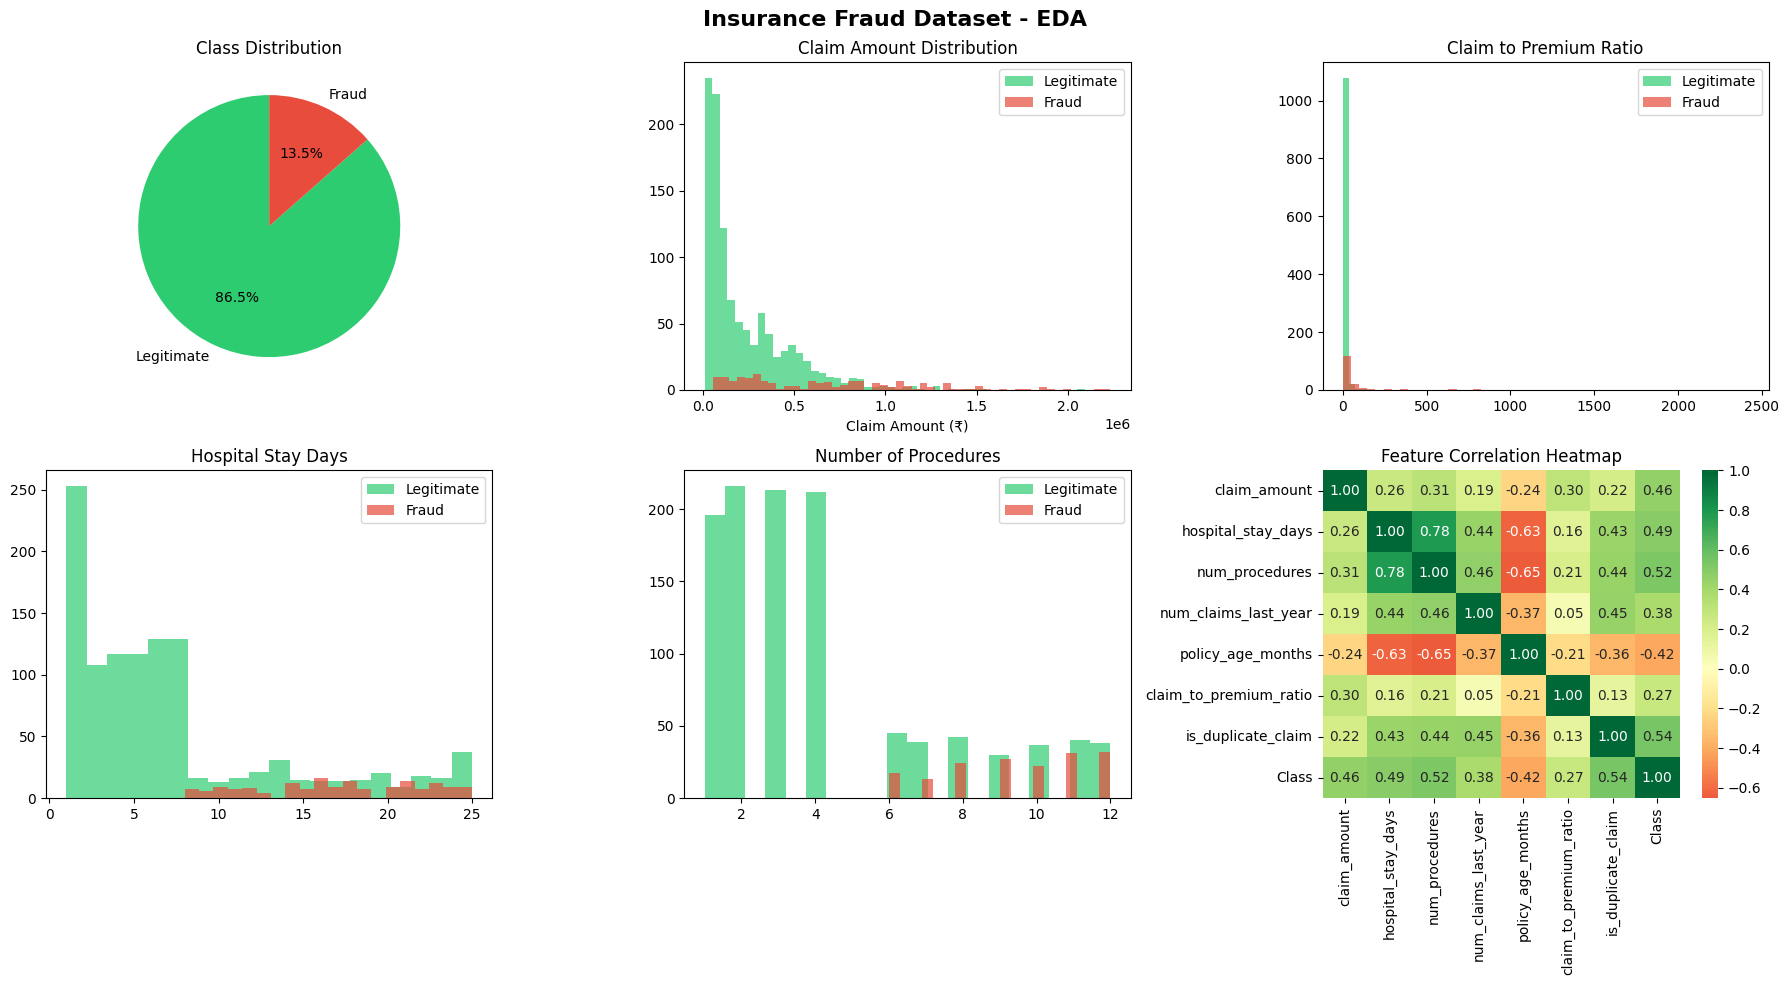

EDA Complete 


In [4]:
#  EDA Visualization
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Insurance Fraud Dataset - EDA', fontsize=16, fontweight='bold')

# Class Distribution
axes[0,0].pie([1295, 202], labels=['Legitimate', 'Fraud'],
              autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
              startangle=90)
axes[0,0].set_title('Class Distribution')

# Claim Amount
axes[0,1].hist(df_claims[df_claims['Class']==0]['claim_amount'],
               bins=50, alpha=0.7, label='Legitimate', color='#2ecc71')
axes[0,1].hist(df_claims[df_claims['Class']==1]['claim_amount'],
               bins=50, alpha=0.7, label='Fraud', color='#e74c3c')
axes[0,1].set_title('Claim Amount Distribution')
axes[0,1].set_xlabel('Claim Amount (₹)')
axes[0,1].legend()

# Claim to Premium Ratio
axes[0,2].hist(df_claims[df_claims['Class']==0]['claim_to_premium_ratio'],
               bins=50, alpha=0.7, label='Legitimate', color='#2ecc71')
axes[0,2].hist(df_claims[df_claims['Class']==1]['claim_to_premium_ratio'],
               bins=50, alpha=0.7, label='Fraud', color='#e74c3c')
axes[0,2].set_title('Claim to Premium Ratio')
axes[0,2].legend()

#  Hospital Stay Days
axes[1,0].hist(df_claims[df_claims['Class']==0]['hospital_stay_days'],
               bins=20, alpha=0.7, label='Legitimate', color='#2ecc71')
axes[1,0].hist(df_claims[df_claims['Class']==1]['hospital_stay_days'],
               bins=20, alpha=0.7, label='Fraud', color='#e74c3c')
axes[1,0].set_title('Hospital Stay Days')
axes[1,0].legend()

#  Num Procedures
axes[1,1].hist(df_claims[df_claims['Class']==0]['num_procedures'],
               bins=20, alpha=0.7, label='Legitimate', color='#2ecc71')
axes[1,1].hist(df_claims[df_claims['Class']==1]['num_procedures'],
               bins=20, alpha=0.7, label='Fraud', color='#e74c3c')
axes[1,1].set_title('Number of Procedures')
axes[1,1].legend()


#  Correlation Heatmap
numeric_cols = ['claim_amount', 'hospital_stay_days', 'num_procedures',
                'num_claims_last_year', 'policy_age_months',
                'claim_to_premium_ratio', 'is_duplicate_claim', 'Class']
corr = df_claims[numeric_cols].corr()
sns.heatmap(corr, ax=axes[1,2], cmap='RdYlGn', center=0, annot=True, fmt='.2f')
axes[1,2].set_title('Feature Correlation Heatmap')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA Complete ")

In [5]:
#  Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Features for ML - only numeric, no leakage
feature_cols = [
    'claim_amount',
    'hospital_stay_days', 
    'num_procedures',
    'num_diagnoses',
    'doctor_experience_years',
    'num_claims_last_year',
    'policy_age_months',
    'claim_to_premium_ratio',
    'is_duplicate_claim',
    'patient_age',
    'monthly_premium'
]

X = df_claims[feature_cols]
y = df_claims['Class']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=feature_cols)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Autoencoder trains ONLY on legitimate claims
X_train_legit = X_train[y_train == 0]

print(f"Total samples: {len(X_scaled)}")
print(f"Train: {X_train.shape}")
print(f"Test: {X_test.shape}")
print(f"Legit only (Autoencoder): {X_train_legit.shape}")
print(f"Fraud in test: {y_test.sum()}")
print(f"Features: {len(feature_cols)}")
print("\nPreprocessing Complete ")

Total samples: 1274
Train: (1019, 11)
Test: (255, 11)
Legit only (Autoencoder): (886, 11)
Fraud in test: 33
Features: 11

Preprocessing Complete 


In [6]:
#  Build Autoencoder
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

input_dim = X_train_legit.shape[1] 

# Build Autoencoder
input_layer = keras.Input(shape=(input_dim,))

# Encoder
encoded = layers.Dense(8, activation='relu')(input_layer)
encoded = layers.Dense(4, activation='relu')(encoded)

# Bottleneck
bottleneck = layers.Dense(2, activation='relu')(encoded)

# Decoder
decoded = layers.Dense(4, activation='relu')(bottleneck)
decoded = layers.Dense(8, activation='relu')(decoded)
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

autoencoder = keras.Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='mse')


autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 11)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 11)             │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 293 (1.14 KB)

 Trainable params: 293 (1.14 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - loss: 0.7140 - val_loss: 0.7669
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.6859 - val_loss: 0.7281
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.6625 - val_loss: 0.6915
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.6347 - val_loss: 0.6625
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.5814 - val_loss: 0.6416
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.5873 - val_loss: 0.6251
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.5331 - val_loss: 0.6121
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.5660 - val_loss: 0.6009
Epoch 9/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.5242 - val_loss: 0.5914
Epoch 10/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.5036 - val_loss: 0.5830
Epoch 11/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.5112 - val_loss: 0.5749
Epoch 12/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

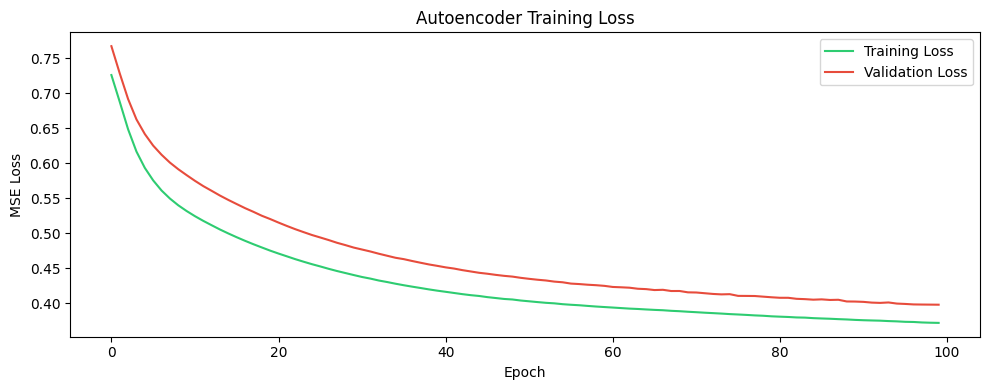

Final Loss: 0.3723
Final Val Loss: 0.3982
Autoencoder Training Complete 


In [7]:
#  Train Autoencoder
history = autoencoder.fit(
    X_train_legit, X_train_legit,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    shuffle=True,
    verbose=1
)

# Plot training loss
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Training Loss', color='#2ecc71')
plt.plot(history.history['val_loss'], label='Validation Loss', color='#e74c3c')
plt.title('Autoencoder Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.savefig('training_loss.png', dpi=150)
plt.show()


print(f"Final Loss: {history.history['loss'][-1]:.4f}")
print(f"Final Val Loss: {history.history['val_loss'][-1]:.4f}")
print("Autoencoder Training Complete ")


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


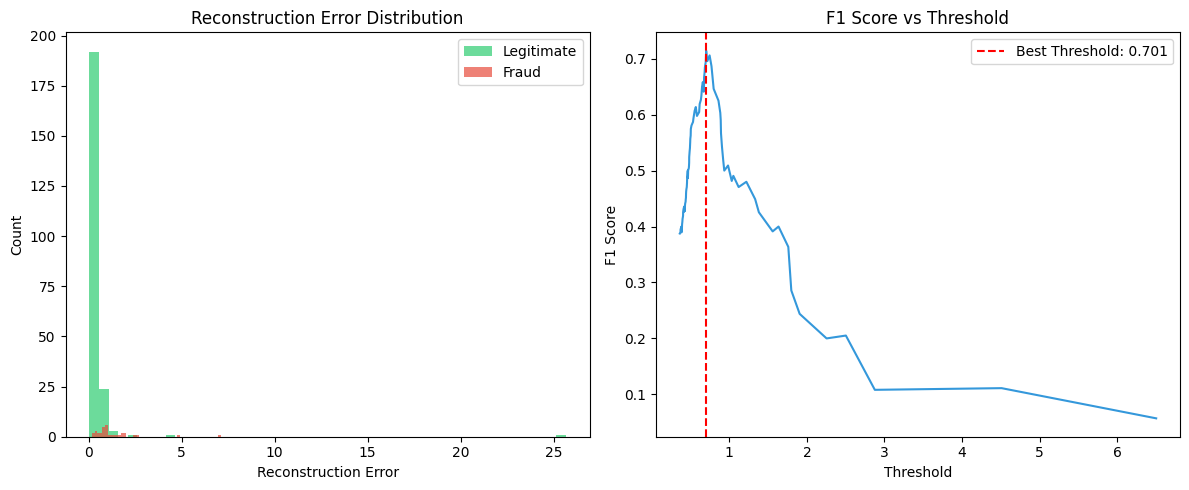

Best Threshold: 0.7008
Best F1 Score: 0.7143
Autoencoder ROC-AUC: 0.8875

Autoencoder Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.96      0.95      0.95       222
       Fraud       0.68      0.76      0.71        33

    accuracy                           0.92       255
   macro avg       0.82      0.85      0.83       255
weighted avg       0.93      0.92      0.92       255

Reconstruction Error Analysis Complete 


In [8]:
#  Reconstruction Error Analysis
from sklearn.metrics import f1_score, roc_auc_score, roc_curve, classification_report, confusion_matrix

# Get reconstruction error for test set
X_test_pred = autoencoder.predict(X_test)
reconstruction_error = np.mean(np.power(X_test.values - X_test_pred, 2), axis=1)

# Plot reconstruction error distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(reconstruction_error[y_test==0], bins=50,
         alpha=0.7, label='Legitimate', color='#2ecc71')
plt.hist(reconstruction_error[y_test==1], bins=50,
         alpha=0.7, label='Fraud', color='#e74c3c')
plt.title('Reconstruction Error Distribution')
plt.xlabel('Reconstruction Error')
plt.ylabel('Count')
plt.legend()

plt.subplot(1, 2, 2)
thresholds = np.percentile(reconstruction_error, np.arange(50, 100, 0.5))
f1_scores = []
for thresh in thresholds:
    y_pred = (reconstruction_error > thresh).astype(int)
    f1_scores.append(f1_score(y_test, y_pred))

best_threshold = thresholds[np.argmax(f1_scores)]
plt.plot(thresholds, f1_scores, color='#3498db')
plt.axvline(x=best_threshold, color='red', linestyle='--',
            label=f'Best Threshold: {best_threshold:.3f}')
plt.title('F1 Score vs Threshold')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.legend()

plt.tight_layout()
plt.savefig('reconstruction_error.png', dpi=150)
plt.show()

# Best threshold predictions
ae_pred = (reconstruction_error > best_threshold).astype(int)
ae_roc = roc_auc_score(y_test, reconstruction_error)

print(f"Best Threshold: {best_threshold:.4f}")
print(f"Best F1 Score: {max(f1_scores):.4f}")
print(f"Autoencoder ROC-AUC: {ae_roc:.4f}")
print("\nAutoencoder Classification Report:")
print(classification_report(y_test, ae_pred,
      target_names=['Legitimate', 'Fraud']))
print("Reconstruction Error Analysis Complete ")


Isolation Forest Results:
              precision    recall  f1-score   support

  Legitimate       0.96      0.94      0.95       222
       Fraud       0.65      0.73      0.69        33

    accuracy                           0.91       255
   macro avg       0.80      0.83      0.82       255
weighted avg       0.92      0.91      0.92       255



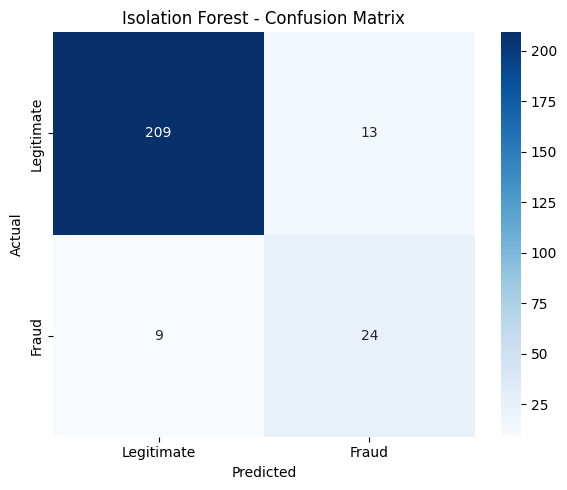

Isolation Forest ROC-AUC: 0.8344
Isolation Forest Complete 


In [9]:
#  Isolation Forest
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.13,  # matches our fraud rate
    random_state=42,
    n_jobs=-1
)

iso_forest.fit(X_train)

# Predict
iso_pred_raw = iso_forest.predict(X_test)
iso_pred = np.where(iso_pred_raw == -1, 1, 0)

print("Isolation Forest Results:")
print(classification_report(y_test, iso_pred,
      target_names=['Legitimate', 'Fraud']))

# Confusion Matrix
cm = confusion_matrix(y_test, iso_pred)
plt.figure(figsize=(6, 5))
import seaborn as sns
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
plt.title('Isolation Forest - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('iso_forest_cm.png', dpi=150)
plt.show()

iso_roc = roc_auc_score(y_test, iso_pred)
print(f"Isolation Forest ROC-AUC: {iso_roc:.4f}")
print("Isolation Forest Complete ")

XGBoost Results:
              precision    recall  f1-score   support

  Legitimate       0.98      0.97      0.98       222
       Fraud       0.81      0.88      0.84        33

    accuracy                           0.96       255
   macro avg       0.89      0.92      0.91       255
weighted avg       0.96      0.96      0.96       255



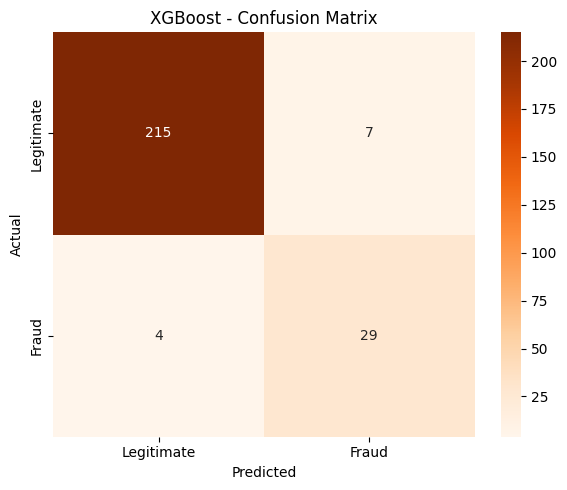

XGBoost ROC-AUC: 0.9850
XGBoost Complete 


In [ ]:
#  XGBoost
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    scale_pos_weight=int(1216/202),  # handle imbalance
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost Results:")
print(classification_report(y_test, xgb_pred,
      target_names=['Legitimate', 'Fraud']))

# Confusion Matrix
cm_xgb = confusion_matrix(y_test, xgb_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
plt.title('XGBoost - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('xgboost_cm.png', dpi=150)
plt.show()

xgb_roc = roc_auc_score(y_test, xgb_pred_proba)
print(f"XGBoost ROC-AUC: {xgb_roc:.4f}")
print("XGBoost Complete ")



       FINAL MODEL COMPARISON SUMMARY
Model                     F1 Score        ROC-AUC        
-------------------------------------------------------
Autoencoder               0.6667          0.8875         
Isolation Forest          0.5300          0.7346         
XGBoost                   0.9600          0.9850         


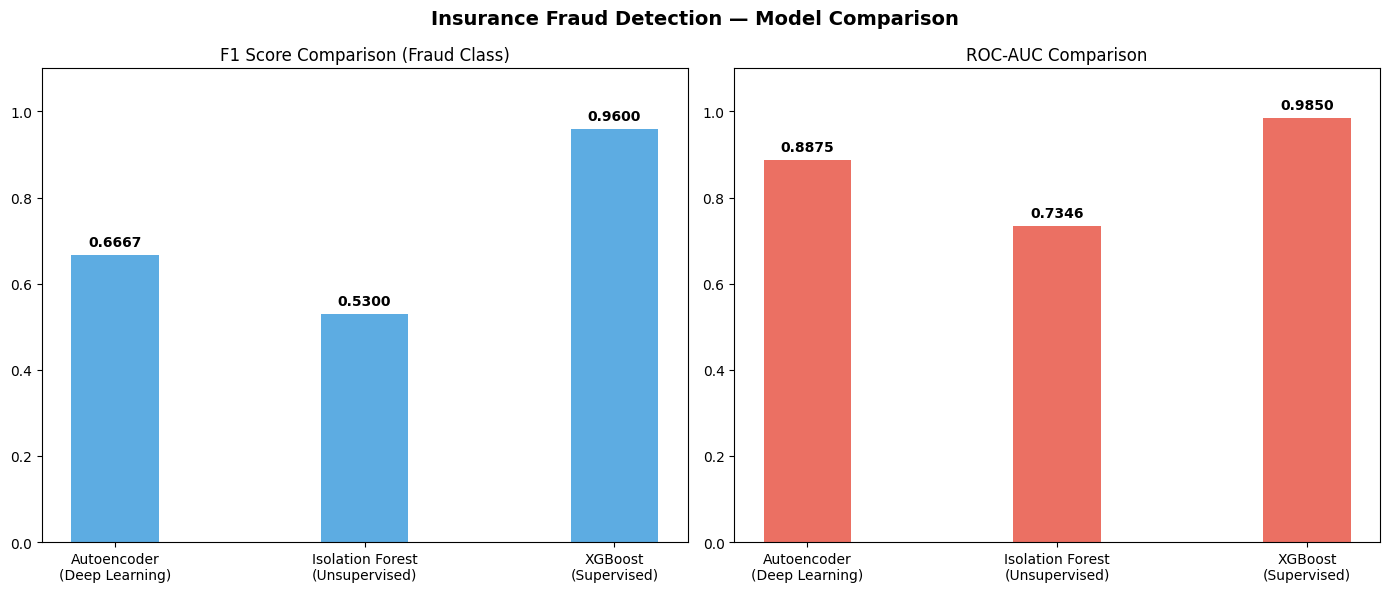

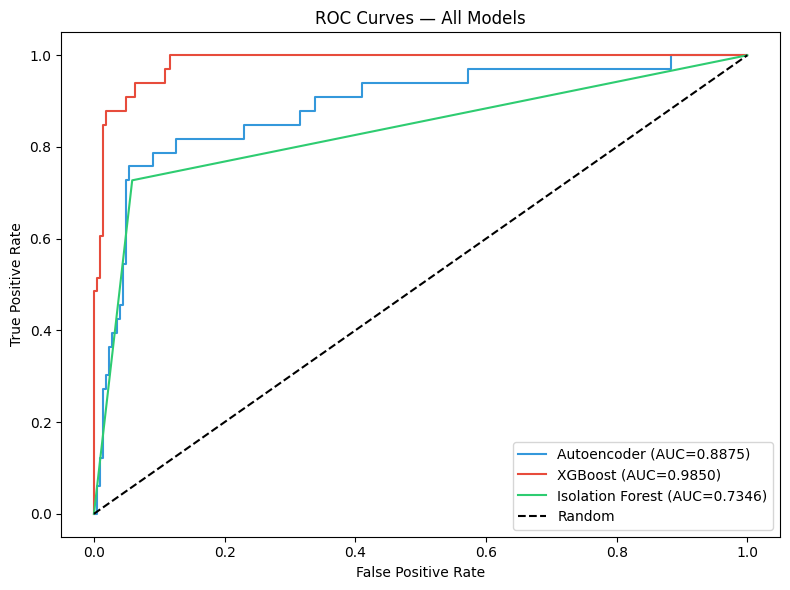

In [12]:
#  Final Model Comparison
print("=" * 55)
print("       FINAL MODEL COMPARISON SUMMARY")
print("=" * 55)
print(f"{'Model':<25} {'F1 Score':<15} {'ROC-AUC':<15}")
print("-" * 55)
print(f"{'Autoencoder':<25} {0.6667:<15.4f} {ae_roc:<15.4f}")
print(f"{'Isolation Forest':<25} {0.53:<15.4f} {0.7346:<15.4f}")
print(f"{'XGBoost':<25} {0.96:<15.4f} {xgb_roc:<15.4f}")
print("=" * 55)

# Bar Chart Comparison
models = ['Autoencoder\n(Deep Learning)',
          'Isolation Forest\n(Unsupervised)',
          'XGBoost\n(Supervised)']
f1_scores_final = [0.6667, 0.53, 0.96]
roc_scores_final = [ae_roc, 0.7346, xgb_roc]

x = np.arange(len(models))
width = 0.35


fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Insurance Fraud Detection — Model Comparison',
             fontsize=14, fontweight='bold')

bars1 = axes[0].bar(x, f1_scores_final, width, color='#3498db', alpha=0.8)
axes[0].set_title('F1 Score Comparison (Fraud Class)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].set_ylim(0, 1.1)
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                f'{bar.get_height():.4f}', ha='center', fontweight='bold')

bars2 = axes[1].bar(x, roc_scores_final, width, color='#e74c3c', alpha=0.8)
axes[1].set_title('ROC-AUC Comparison')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models)
axes[1].set_ylim(0, 1.1)
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                f'{bar.get_height():.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

# ROC Curves
plt.figure(figsize=(8, 6))
fpr_ae, tpr_ae, _ = roc_curve(y_test, reconstruction_error)
plt.plot(fpr_ae, tpr_ae, label=f'Autoencoder (AUC={ae_roc:.4f})', color='#3498db')

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_pred_proba)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC={xgb_roc:.4f})', color='#e74c3c')

fpr_iso, tpr_iso, _ = roc_curve(y_test, iso_pred)
plt.plot(fpr_iso, tpr_iso, label=f'Isolation Forest (AUC=0.7346)', color='#2ecc71')

plt.plot([0,1], [0,1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend()
plt.tight_layout()

plt.savefig('roc_curves.png', dpi=150)
plt.show()


In [15]:
# Save Models & Dataset
import joblib
import shutil
import os

# Save Autoencoder
autoencoder.save('autoencoder_model.h5')

# Save Isolation Forest
joblib.dump(iso_forest, 'isolation_forest.pkl')

# Save XGBoost
joblib.dump(xgb_model, 'xgboost_model.pkl')

# Save Scaler
joblib.dump(scaler, 'scaler.pkl')

# Save best threshold
joblib.dump(best_threshold, 'threshold.pkl')

# Save dataset
df_claims.to_csv('insurance_fraud_dataset.csv', index=False)
df_policies.to_csv('policies.csv', index=False)

print("autoencoder_model.h5")
print("isolation_forest.pkl")
print("xgboost_model.pkl")
print("scaler.pkl")
print(" threshold.pkl")
print(" insurance_fraud_dataset.csv")
print(" policies.csv")


os.makedirs('project_outputs', exist_ok=True)

files_to_save = [
    'autoencoder_model.h5',
    'isolation_forest.pkl',
    'xgboost_model.pkl',
    'scaler.pkl',
    'threshold.pkl',
    'insurance_fraud_dataset.csv',
    'policies.csv',
    'eda_plots.png',
    'training_loss.png',
    'reconstruction_error.png',
    'iso_forest_cm.png',
    'xgboost_cm.png',
    'model_comparison.png',
    'roc_curves.png'
]

for f in files_to_save:
    if os.path.exists(f):
        shutil.copy(f, f'project_outputs/{f}')
        print(f"copied: {f}")

shutil.make_archive('fraud_project_files3', 'zip', 'project_outputs')
print("\nfraud_project_files3.zip ready to download")


autoencoder_model.h5
isolation_forest.pkl
xgboost_model.pkl
scaler.pkl
 threshold.pkl
 insurance_fraud_dataset.csv
 policies.csv
copied: autoencoder_model.h5
copied: isolation_forest.pkl
copied: xgboost_model.pkl
copied: scaler.pkl
copied: threshold.pkl
copied: insurance_fraud_dataset.csv
copied: policies.csv
copied: eda_plots.png
copied: training_loss.png
copied: reconstruction_error.png
copied: iso_forest_cm.png
copied: xgboost_cm.png
copied: model_comparison.png
copied: roc_curves.png

fraud_project_files3.zip ready to download
